In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
ndvi_semanal = pd.read_csv('../Etapa 3/ndvi_semanal_estaciones_2021_2025.csv') # NDVI
NE3 = pd.read_csv('../data_estaciones/BD_NE3.csv') # Pesquería
NE2 = pd.read_csv('../data_estaciones/BD_NE2.csv') # Apodaca

In [3]:
# Rangos validos segun SIMA. Los valores fuera de estos limites se reemplazan por NaN.
rangos_validos = {
    'PM10': (0, 999),
    'PM2.5': (0, 999),
    'O3': (0, 185),
    'NO': (0, 500),
    'NO2': (0, 200),
    'SO2': (0, 405),
    'CO': (0, 20),
    'RH': (0, 100),
    'WSR': (0, 75),
    'TOUT': (-6.5, 45.5),
    'SR': (0, 1.26),
    'WDR': (0, 360),
    'RAINF': (0, 80)
}

estaciones = [NE2, NE3]  # Lista de DataFrames de estaciones

for nombre, estacion in zip(['NE2', 'NE3'], estaciones):
    valores_eliminados = 0

    for columna, (minimo, maximo) in rangos_validos.items():
        if columna in estacion.columns:
            valores = pd.to_numeric(estacion[columna], errors='coerce')
            fuera_de_rango = (valores < minimo) | (valores > maximo)
            valores_eliminados += fuera_de_rango.sum()
            estacion.loc[fuera_de_rango, columna] = pd.NA

    print(f'{nombre}: {valores_eliminados} valores fuera de rango reemplazados por NaN')

NE2: 74 valores fuera de rango reemplazados por NaN
NE3: 95 valores fuera de rango reemplazados por NaN


In [34]:
ndvi_NE2 = ndvi_semanal[ndvi_semanal["estacion"] == "NE2"].copy()
ndvi_NE3 = ndvi_semanal[ndvi_semanal["estacion"] == "NE3"].copy()

In [38]:
len(ndvi_NE2) == len(ndvi_NE3)

True

In [39]:
len(ndvi_NE2)

261

Se debe de transformar la variable WDR (Dirección del viento) porque está en grados.

In [ ]:
# Transformación de WDR a cuadrantes categóricos

def obtener_cuadrante_8(grados):
    """
    Clasifica los grados (0-360) en 8 rumbos principales.
    Mantiene los nulos (NaN) intactos.
    """
    if pd.isna(grados):
        return np.nan
    
    # Asegurar que esté en el rango 0-360
    grados = grados % 360
    
    if grados >= 337.5 or grados < 22.5:
        return 'N'
    elif 22.5 <= grados < 67.5:
        return 'NE'
    elif 67.5 <= grados < 112.5:
        return 'E'
    elif 112.5 <= grados < 157.5:
        return 'SE'
    elif 157.5 <= grados < 202.5:
        return 'S'
    elif 202.5 <= grados < 247.5:
        return 'SO'
    elif 247.5 <= grados < 292.5:
        return 'O'
    elif 292.5 <= grados < 337.5:
        return 'NO'

# 1. Aplicar la función a la columna WDR
NE2['WDR_Cuadrante'] = NE2['WDR'].apply(obtener_cuadrante_8)

# 2. Generar las variables dummy (0 o 1) para el modelo econométrico/regresión
# dummy_na=False asegura que los NaN de origen no se conviertan en una categoría válida
dummies_viento = pd.get_dummies(NE2['WDR_Cuadrante'], prefix='WDR', dummy_na=False, dtype=int)

# 3. Unir las columnas al DataFrame principal
NE2 = pd.concat([NE2, dummies_viento], axis=1)

# Eliminar la columna original de WDR_Cuadrante si no es necesaria
NE2.drop(columns=['WDR_Cuadrante'], inplace=True)

NE3['WDR_Cuadrante'] = NE3['WDR'].apply(obtener_cuadrante_8)
dummies_viento_NE3 = pd.get_dummies(NE3['WDR_Cuadrante'], prefix='WDR', dummy_na=False, dtype=int)
NE3 = pd.concat([NE3, dummies_viento_NE3], axis=1)
NE3.drop(columns=['WDR_Cuadrante'], inplace=True)

In [ ]:
NE2.columns

Index(['ID', 'time', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2.5', 'PRS',
       'RAINF', 'RH', 'SO2', 'SR', 'TOUT', 'WSR', 'WDR', 'WDR_E', 'WDR_N',
       'WDR_NE', 'WDR_NO', 'WDR_O', 'WDR_S', 'WDR_SE', 'WDR_SO'],
      dtype='str')

<Axes: >

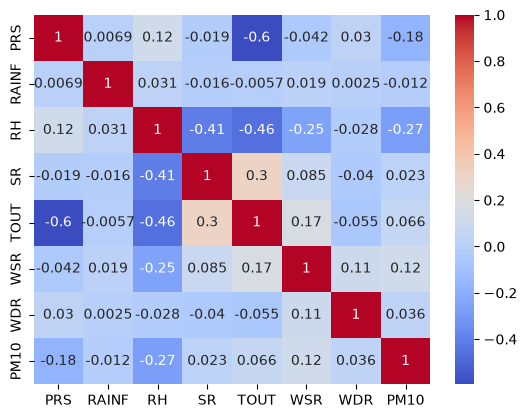

In [9]:
# Mapa de correlación NE2

import seaborn as sns

sns.heatmap(NE2[cols].corr(), annot=True, cmap='coolwarm')

<Axes: >

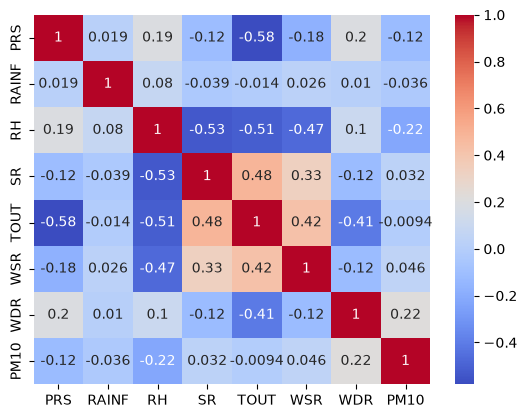

In [10]:
sns.heatmap(NE3[cols].corr(), annot=True, cmap='coolwarm')

<Axes: >

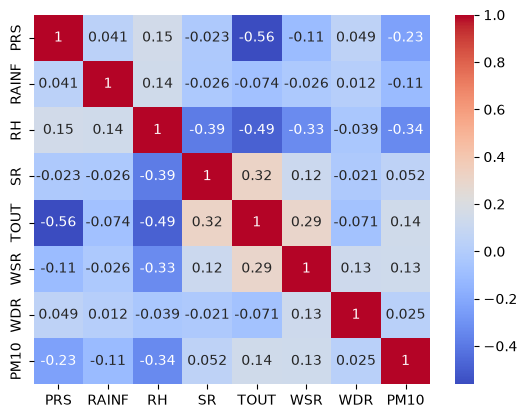

In [11]:
# Matriz de correlación de spearman NE2

sns.heatmap(NE2[cols].corr(method='spearman'), annot=True, cmap='coolwarm')

<Axes: >

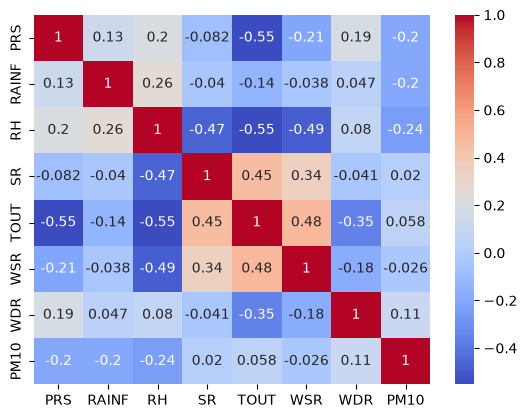

In [12]:
sns.heatmap(NE3[cols].corr(method='spearman'), annot=True, cmap='coolwarm')

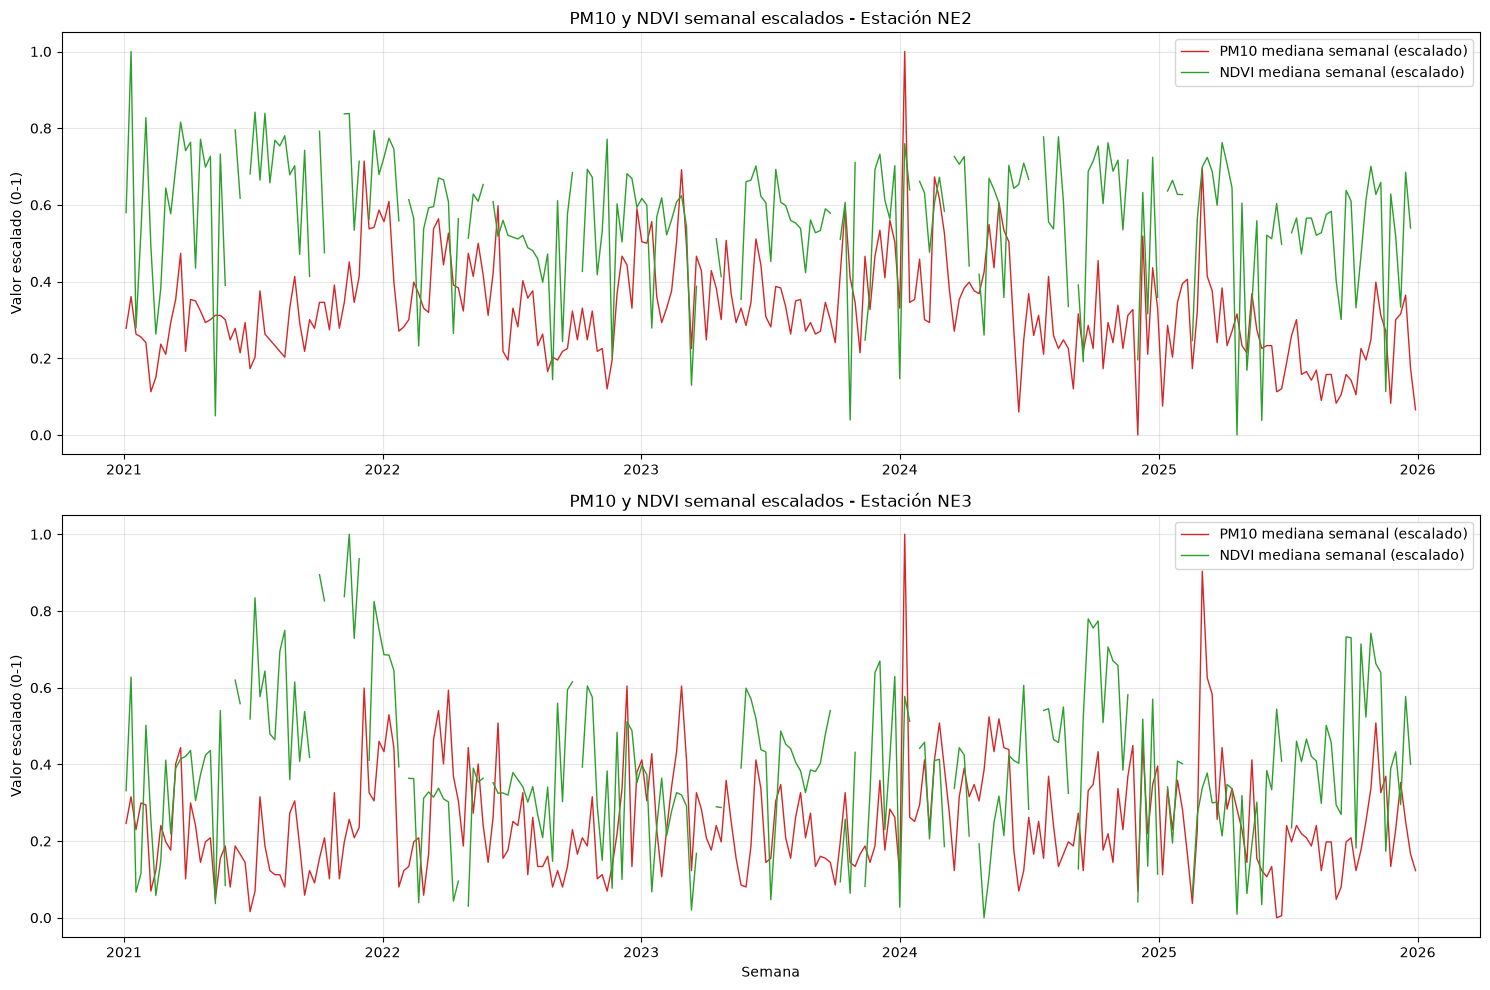

(      semana  pm10_mediana  ndvi_mediana  pm10_escalado  ndvi_escalado
 0 2021-01-04          54.0      0.043589       0.278195       0.579641
 1 2021-01-11          65.0      0.111654       0.360902       1.000000
 2 2021-01-18          52.0     -0.005069       0.263158       0.279136
 3 2021-01-25          51.0      0.035765       0.255639       0.531320
 4 2021-02-01          49.0      0.083736       0.240602       0.827580,
       semana  pm10_mediana  ndvi_mediana  pm10_escalado  ndvi_escalado
 0 2021-01-04          33.5      0.148724       0.245989       0.331333
 1 2021-01-11          40.0      0.319332       0.315508       0.627766
 2 2021-01-18          32.0     -0.003552       0.229947       0.066750
 3 2021-01-25          38.5      0.024677       0.299465       0.115798
 4 2021-02-01          38.0      0.246958       0.294118       0.502015)

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


def escalar_min_max(serie):
    """Escala una serie al intervalo [0, 1], ignorando valores faltantes."""
    minimo = serie.min()
    maximo = serie.max()
    if pd.isna(minimo) or minimo == maximo:
        return serie * 0
    return (serie - minimo) / (maximo - minimo)


def semana_de(fecha):
    """Devuelve el lunes de la semana ISO a la que pertenece una fecha."""
    return pd.Timestamp(fecha).to_period("W-SUN").start_time


def preparar_datos_estacion(datos_pm10, nombre_estacion):
    """Agrega PM10 por semana y lo combina con el NDVI semanal."""
    pm10_semanal = (
        datos_pm10.assign(
            semana=datos_pm10["date"].apply(semana_de),
            PM10=pd.to_numeric(datos_pm10["PM10"], errors="coerce"),
        )
        .groupby("semana", as_index=False)["PM10"]
        .median()
        .rename(columns={"PM10": "pm10_mediana"})
    )

    ndvi_estacion = ndvi_semanal.loc[
        ndvi_semanal["estacion"] == nombre_estacion,
        ["semana", "ndvi_mediana"],
    ]
    datos = pm10_semanal.merge(ndvi_estacion, on="semana", how="inner")
    datos = datos.sort_values("semana")
    datos["pm10_escalado"] = escalar_min_max(datos["pm10_mediana"])
    datos["ndvi_escalado"] = escalar_min_max(datos["ndvi_mediana"])
    return datos


# El CSV guarda "semana" como texto; se convierte al mismo tipo que usa PM10.
ndvi_semanal["semana"] = pd.to_datetime(ndvi_semanal["semana"])
NE2["date"] = pd.to_datetime(NE2["date"])
NE3["date"] = pd.to_datetime(NE3["date"])

serie_NE2 = preparar_datos_estacion(NE2, "NE2")
serie_NE3 = preparar_datos_estacion(NE3, "NE3")

fig, ejes = plt.subplots(2, 1, figsize=(15, 10), sharey=True)

for eje, datos, nombre_estacion in zip(
    ejes,
    [serie_NE2, serie_NE3],
    ["NE2", "NE3"],
):
    eje.plot(
        datos["semana"],
        datos["pm10_escalado"],
        label="PM10 mediana semanal (escalado)",
        color="tab:red",
        linewidth=1.0,
    )
    eje.plot(
        datos["semana"],
        datos["ndvi_escalado"],
        label="NDVI mediana semanal (escalado)",
        color="tab:green",
        linewidth=1.0,
    )
    eje.set_title(f"PM10 y NDVI semanal escalados - Estación {nombre_estacion}")
    eje.set_ylabel("Valor escalado (0-1)")
    eje.grid(True, alpha=0.3)
    eje.legend()

# NE3 empieza en 2021 porque no tiene observaciones de 2020.
ejes[-1].set_xlabel("Semana")
plt.tight_layout()
plt.show()

serie_NE2.head(), serie_NE3.head()

In [14]:

# Correlación entre PM10 y NDVI para la estación NE2
correlacion_NE2 = serie_NE2["pm10_mediana"].corr(serie_NE2["ndvi_mediana"])

# Correlación entre PM10 y NDVI para la estación NE3
correlacion_NE3 = serie_NE3["pm10_mediana"].corr(serie_NE3["ndvi_mediana"])

correlacion_NE2, correlacion_NE3

(np.float64(0.21370115638306988), np.float64(0.0338823129860763))

In [15]:

# Correlación entre PM10 y NDVI para la estación NE2
correlacion_NE2 = serie_NE2["pm10_mediana"].corr(serie_NE2["ndvi_mediana"],method='spearman')

# Correlación entre PM10 y NDVI para la estación NE3
correlacion_NE3 = serie_NE3["pm10_mediana"].corr(serie_NE3["ndvi_mediana"],method='spearman')

correlacion_NE2, correlacion_NE3

(np.float64(0.20454697468470864), np.float64(0.026747397566009003))

In [16]:
# Correlacion estacional entre la mediana mensual de PM10 y NDVI
# Se usan solamente observaciones desde enero de 2022.
def agregar_estacion(mes):
    estaciones = {
        12: "Invierno", 1: "Invierno", 2: "Invierno",
        3: "Primavera", 4: "Primavera", 5: "Primavera",
        6: "Verano", 7: "Verano", 8: "Verano",
        9: "Otono", 10: "Otono", 11: "Otono",
    }
    return estaciones[mes]

series_desde_2022 = pd.concat(
    [
        serie_NE2.assign(estacion="NE2"),
        serie_NE3.assign(estacion="NE3"),
    ],
    ignore_index=True,
)
series_desde_2022["semana"] = pd.to_datetime(series_desde_2022["semana"])
series_desde_2022 = series_desde_2022.loc[
    series_desde_2022["semana"] >= "2022-01-01"
].copy()
series_desde_2022["estacion_climatica"] = series_desde_2022["semana"].dt.month.map(agregar_estacion)

# Cada fila conserva las medianas mensuales ya calculadas para PM10 y NDVI.
correlacion_estacional = (
    series_desde_2022.groupby(["estacion", "estacion_climatica"])
    .apply(
        lambda grupo: pd.Series(
            {
                "pearson": grupo["pm10_mediana"].corr(
                    grupo["ndvi_mediana"], method="pearson"
                ),
                "spearman": grupo["pm10_mediana"].corr(
                    grupo["ndvi_mediana"], method="spearman"
                ),
                "meses_usados": grupo[[
                    "pm10_mediana",
                    "ndvi_mediana",
                ]].dropna().shape[0],
            }
        )
    )
    .reset_index()
)

print("Correlacion estacional desde 2022:")
display(correlacion_estacional)

print("Medianas mensuales usadas en el calculo:")
display(
    series_desde_2022[
        ["estacion", "semana", "estacion_climatica", "pm10_mediana", "ndvi_mediana"]
    ]
)

Correlacion estacional desde 2022:


,estacion,estacion_climatica,pearson,spearman,meses_usados
0,NE2,Invierno,0.480721,0.450306,48.0
1,NE2,Otono,0.078943,0.145160,47.0
2,NE2,Primavera,0.342879,0.238285,44.0
3,NE2,Verano,0.207429,0.201791,49.0
4,NE3,Invierno,0.424957,0.462747,48.0
5,NE3,Otono,0.421973,0.479475,47.0
6,NE3,Primavera,0.071421,0.044844,44.0
7,NE3,Verano,0.091413,0.110299,49.0


Medianas mensuales usadas en el calculo:


,estacion,semana,estacion_climatica,pm10_mediana,ndvi_mediana
52,NE2,2022-01-03,Invierno,91.0,0.067021
53,NE2,2022-01-10,Invierno,98.0,0.075065
54,NE2,2022-01-17,Invierno,70.0,0.070435
55,NE2,2022-01-24,Invierno,53.0,0.040136
56,NE2,2022-01-31,Invierno,54.5,NaN
...,...,...,...,...,...
517,NE3,2025-12-01,Invierno,32.0,0.207161
518,NE3,2025-12-08,Invierno,43.5,0.127926
519,NE3,2025-12-15,Invierno,34.0,0.290158
520,NE3,2025-12-22,Invierno,26.0,0.188602


In [ ]:
series_desde_2022.head()

,mes,pm10_mediana,ndvi_mediana,pm10_escalado,ndvi_escalado,estacion,estacion_climatica
24,2022-01-01,74.500000,0.070435,0.742647,0.640612,NE2,Invierno
25,2022-02-01,63.387087,0.041327,0.579222,0.366099,NE2,Invierno
26,2022-03-01,73.000000,0.045687,0.720588,0.407217,NE2,Primavera
27,2022-04-01,70.000000,0.033386,0.676471,0.291204,NE2,Primavera
28,2022-05-01,75.000000,0.050879,0.750000,0.456175,NE2,Primavera


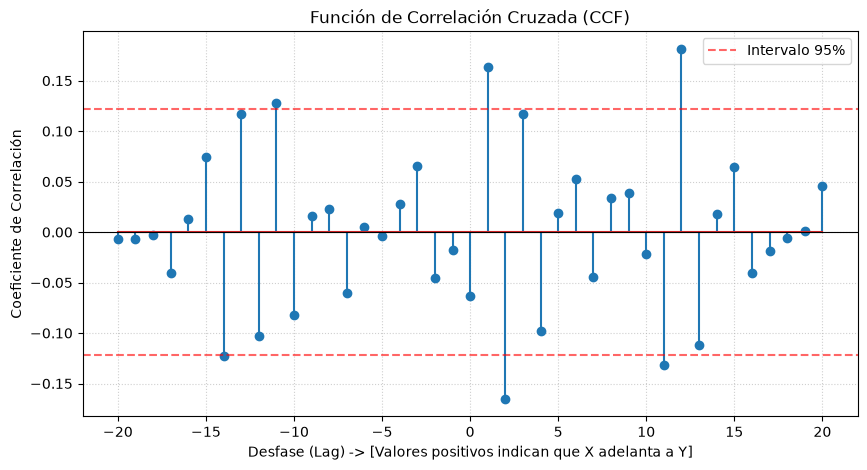

In [17]:
from statsmodels.tsa.stattools import ccf

x_raw = serie_NE2["pm10_mediana"].dropna()
y_raw = serie_NE2["ndvi_mediana"].dropna()

x = np.diff(x_raw)
y = np.diff(y_raw)

# 4. Opción B: Correlación cruzada bidireccional con numpy (Lags negativos y positivos)
lags = np.arange(-20, 21)
# Normalización para obtener valores entre -1 y 1
norm_x = (x - np.mean(x)) / (np.std(x) * len(x))
norm_y = (y - np.mean(y)) / np.std(y)
ccf_numpy = np.correlate(norm_x, norm_y, mode='full')
mid_point = len(ccf_numpy) // 2
ccf_bidireccional = ccf_numpy[mid_point - 20 : mid_point + 21]

# 5. Visualización del gráfico de Correlación Cruzada (CCF)
plt.figure(figsize=(10, 5))
plt.stem(lags, ccf_bidireccional)

# Límites de significancia estadística (~95% confianza)
conf_level = 1.96 / np.sqrt(len(x))
plt.axhline(y=conf_level, color='r', linestyle='--', alpha=0.6, label='Intervalo 95%')
plt.axhline(y=-conf_level, color='r', linestyle='--', alpha=0.6)
plt.axhline(y=0, color='black', linewidth=0.8)

plt.title('Función de Correlación Cruzada (CCF)')
plt.xlabel('Desfase (Lag) -> [Valores positivos indican que X adelanta a Y]')
plt.ylabel('Coeficiente de Correlación')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

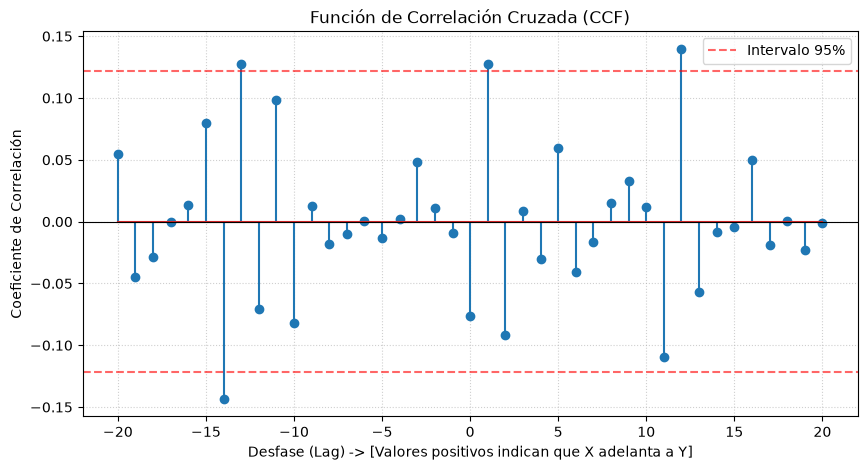

In [18]:
from statsmodels.tsa.stattools import ccf

x_raw = serie_NE3["pm10_mediana"].dropna()
y_raw = serie_NE3["ndvi_mediana"].dropna()

x = np.diff(x_raw)
y = np.diff(y_raw)

# 4. Opción B: Correlación cruzada bidireccional con numpy (Lags negativos y positivos)
lags = np.arange(-20, 21)
# Normalización para obtener valores entre -1 y 1
norm_x = (x - np.mean(x)) / (np.std(x) * len(x))
norm_y = (y - np.mean(y)) / np.std(y)
ccf_numpy = np.correlate(norm_x, norm_y, mode='full')
mid_point = len(ccf_numpy) // 2
ccf_bidireccional = ccf_numpy[mid_point - 20 : mid_point + 21]

# 5. Visualización del gráfico de Correlación Cruzada (CCF)
plt.figure(figsize=(10, 5))
plt.stem(lags, ccf_bidireccional)

# Límites de significancia estadística (~95% confianza)
conf_level = 1.96 / np.sqrt(len(x))
plt.axhline(y=conf_level, color='r', linestyle='--', alpha=0.6, label='Intervalo 95%')
plt.axhline(y=-conf_level, color='r', linestyle='--', alpha=0.6)
plt.axhline(y=0, color='black', linewidth=0.8)

plt.title('Función de Correlación Cruzada (CCF)')
plt.xlabel('Desfase (Lag) -> [Valores positivos indican que X adelanta a Y]')
plt.ylabel('Coeficiente de Correlación')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

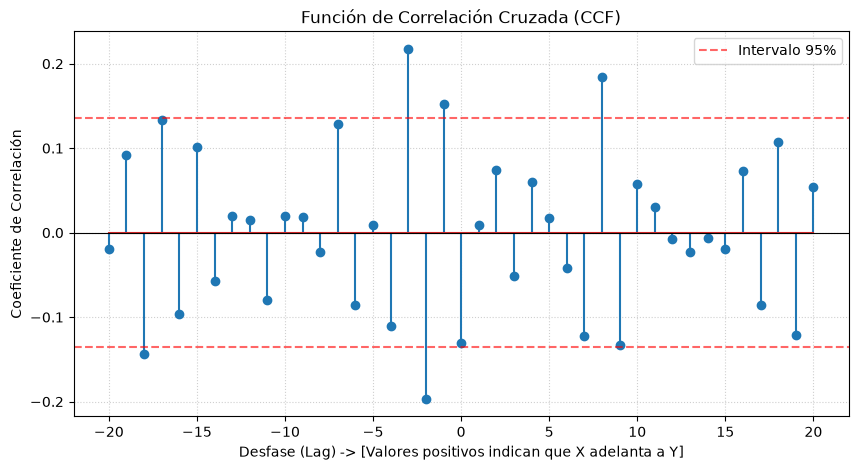

In [19]:
from statsmodels.tsa.stattools import ccf

serie_NE2_desde2022 = serie_NE2.loc[serie_NE2["semana"] >= "2022-01-01"].copy()

x_raw = serie_NE2_desde2022["pm10_mediana"].dropna()
y_raw = serie_NE2_desde2022["ndvi_mediana"].dropna()

x = np.diff(x_raw)
y = np.diff(y_raw)

# 4. Opción B: Correlación cruzada bidireccional con numpy (Lags negativos y positivos)
lags = np.arange(-20, 21)
# Normalización para obtener valores entre -1 y 1
norm_x = (x - np.mean(x)) / (np.std(x) * len(x))
norm_y = (y - np.mean(y)) / np.std(y)
ccf_numpy = np.correlate(norm_x, norm_y, mode='full')
mid_point = len(ccf_numpy) // 2
ccf_bidireccional = ccf_numpy[mid_point - 20 : mid_point + 21]

# 5. Visualización del gráfico de Correlación Cruzada (CCF)
plt.figure(figsize=(10, 5))
plt.stem(lags, ccf_bidireccional)

# Límites de significancia estadística (~95% confianza)
conf_level = 1.96 / np.sqrt(len(x))
plt.axhline(y=conf_level, color='r', linestyle='--', alpha=0.6, label='Intervalo 95%')
plt.axhline(y=-conf_level, color='r', linestyle='--', alpha=0.6)
plt.axhline(y=0, color='black', linewidth=0.8)

plt.title('Función de Correlación Cruzada (CCF)')
plt.xlabel('Desfase (Lag) -> [Valores positivos indican que X adelanta a Y]')
plt.ylabel('Coeficiente de Correlación')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

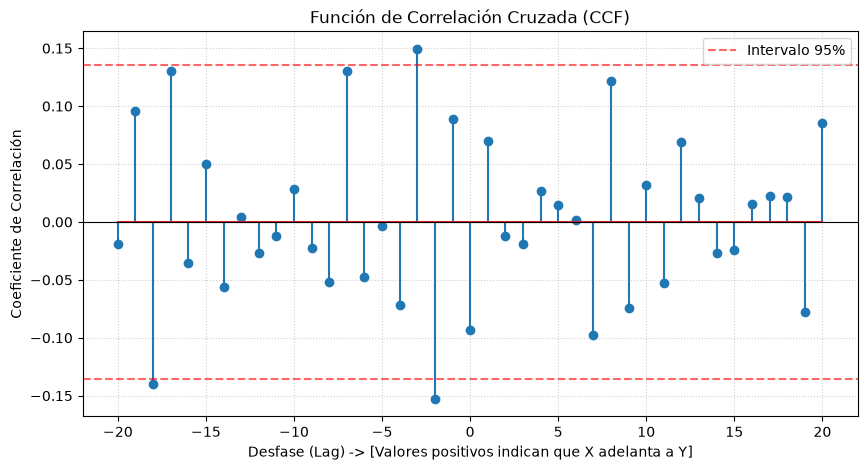

In [20]:
from statsmodels.tsa.stattools import ccf

serie_NE3_desde2022 = serie_NE3.loc[serie_NE3["semana"] >= "2022-01-01"].copy()

x_raw = serie_NE3_desde2022["pm10_mediana"].dropna()
y_raw = serie_NE3_desde2022["ndvi_mediana"].dropna()

x = np.diff(x_raw)
y = np.diff(y_raw)

# 4. Opción B: Correlación cruzada bidireccional con numpy (Lags negativos y positivos)
lags = np.arange(-20, 21)
# Normalización para obtener valores entre -1 y 1
norm_x = (x - np.mean(x)) / (np.std(x) * len(x))
norm_y = (y - np.mean(y)) / np.std(y)
ccf_numpy = np.correlate(norm_x, norm_y, mode='full')
mid_point = len(ccf_numpy) // 2
ccf_bidireccional = ccf_numpy[mid_point - 20 : mid_point + 21]

# 5. Visualización del gráfico de Correlación Cruzada (CCF)
plt.figure(figsize=(10, 5))
plt.stem(lags, ccf_bidireccional)

# Límites de significancia estadística (~95% confianza)
conf_level = 1.96 / np.sqrt(len(x))
plt.axhline(y=conf_level, color='r', linestyle='--', alpha=0.6, label='Intervalo 95%')
plt.axhline(y=-conf_level, color='r', linestyle='--', alpha=0.6)
plt.axhline(y=0, color='black', linewidth=0.8)

plt.title('Función de Correlación Cruzada (CCF)')
plt.xlabel('Desfase (Lag) -> [Valores positivos indican que X adelanta a Y]')
plt.ylabel('Coeficiente de Correlación')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

<Axes: title={'center': 'NE2: PM10 vs NDVI'}, xlabel='pm10_mediana', ylabel='ndvi_mediana'>

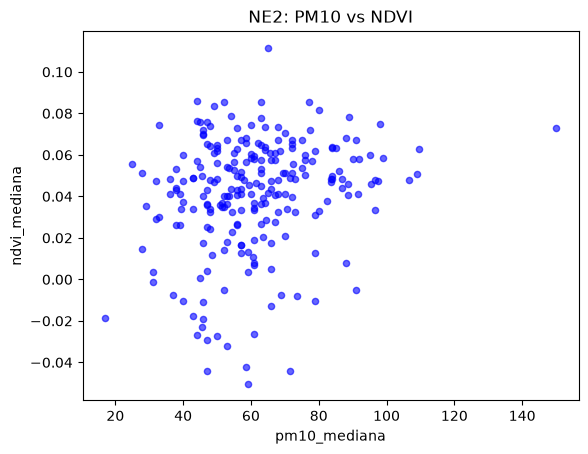

In [21]:
serie_NE2.plot(x='pm10_mediana', y='ndvi_mediana', kind='scatter', alpha=0.6, color='blue', title='NE2: PM10 vs NDVI')

<Axes: title={'center': 'NE3: PM10 vs NDVI'}, xlabel='pm10_mediana', ylabel='ndvi_mediana'>

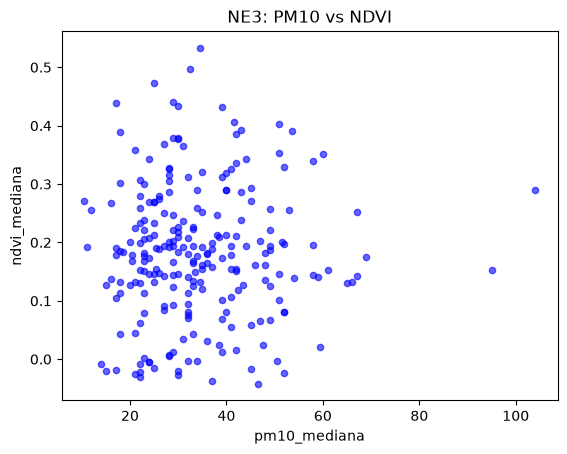

In [22]:
serie_NE3.plot(x='pm10_mediana', y='ndvi_mediana', kind='scatter', alpha=0.6, color='blue', title='NE3: PM10 vs NDVI')